# Phase 3.7 — Residual Sanity Check

Before using residuals for anomaly detection, we verify the fundamental assumption: **residuals should be near-zero during normal operation and systematically elevated during anomaly events.**

This notebook performs three validation steps:
1. **Visual comparison** — violin/box plots of residual distributions (normal vs anomaly) per subsystem
2. **Statistical testing** — Mann-Whitney U tests to confirm the separation is statistically significant
3. **Per-event heatmap** — bird's-eye view of which events show elevated residuals and in which subsystems
4. **Best/worst cases** — identify strongest detections, missed anomalies, and potential false alarms

In [1]:
import json
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import mannwhitneyu

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", font_scale=1.1)

# --- paths ---
PROJECT = Path(r"D:\Personal Projects\Enbridge Case Compettion")
RESIDUALS_DIR = PROJECT / "data" / "processed" / "residuals"
EVENTS_CSV = PROJECT / "data" / "processed" / "unified_events.csv"
SUMMARY_JSON = PROJECT / "outputs" / "reports" / "residuals_summary.json"
FIGURES_DIR = PROJECT / "outputs" / "figures"
REPORTS_DIR = PROJECT / "outputs" / "reports"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

# human-readable labels
SUBSYSTEM_LABELS = {
    "gearbox": "Gearbox",
    "generator_bearings": "Generator Bearings",
    "transformer": "Transformer",
    "hydraulic": "Hydraulic",
    "cooling": "Cooling",
}

FARM_LABELS = {"a": "Farm A", "b": "Farm B", "c": "Farm C"}
FARMS = ["a", "b", "c"]

# --- load event info ---
events_df = pd.read_csv(EVENTS_CSV)
events_df["farm"] = events_df["farm"].str.upper()
print(f"Loaded {len(events_df)} events")
print(events_df["event_label"].value_counts())

# --- load residuals summary ---
with open(SUMMARY_JSON) as f:
    residuals_summary = json.load(f)
print(f"\nResiduals summary loaded for farms: {list(residuals_summary.keys())}")

Loaded 95 events
event_label
normal     50
anomaly    45
Name: count, dtype: int64

Residuals summary loaded for farms: ['A', 'B', 'C']


In [2]:
def load_prediction_residuals(farm: str, event_id: int) -> pd.DataFrame | None:
    """Load residuals for a single event, filtered to prediction window only."""
    path = RESIDUALS_DIR / f"farm_{farm}" / f"event_{event_id}.parquet"
    if not path.exists():
        return None
    df = pd.read_parquet(path)
    pred = df[df["train_test"] == "prediction"].copy()
    if pred.empty:
        return None
    return pred


def get_subsystems(df: pd.DataFrame) -> list[str]:
    """Extract subsystem names from residual columns."""
    return [c.replace("_residual", "") for c in df.columns if c.endswith("_residual")]


def compute_event_mean_residuals(farm: str) -> pd.DataFrame:
    """Compute mean absolute residual per event per subsystem (prediction window only)."""
    farm_dir = RESIDUALS_DIR / f"farm_{farm}"
    farm_events = events_df[events_df["farm"] == farm.upper()]
    rows = []
    for _, ev in farm_events.iterrows():
        pred = load_prediction_residuals(farm, ev["event_id"])
        if pred is None:
            continue
        subsystems = get_subsystems(pred)
        row = {
            "farm": farm.upper(),
            "event_id": ev["event_id"],
            "event_label": ev["event_label"],
            "event_description": ev.get("event_description", ""),
            "asset_id": ev.get("asset_id", ""),
        }
        for sub in subsystems:
            col = f"{sub}_residual"
            row[f"{sub}_mean_abs"] = pred[col].abs().mean()
            row[f"{sub}_mean"] = pred[col].mean()
        rows.append(row)
    return pd.DataFrame(rows)


# build the master table
all_event_stats = pd.concat(
    [compute_event_mean_residuals(f) for f in FARMS], ignore_index=True
)
print(f"Computed prediction-window residual stats for {len(all_event_stats)} events")
all_event_stats.head()

Computed prediction-window residual stats for 95 events


,farm,event_id,event_label,event_description,asset_id,gearbox_mean_abs,gearbox_mean,generator_bearings_mean_abs,generator_bearings_mean,transformer_mean_abs,transformer_mean,hydraulic_mean_abs,hydraulic_mean,cooling_mean_abs,cooling_mean
0,A,68,anomaly,Transformer failure,11,1.628641,0.188894,3.439378,0.906962,9.525258,9.295605,2.489931,0.093336,1.089711,-0.214615
1,A,22,anomaly,Hydraulic group,21,1.951688,1.004846,4.424371,0.001982,5.981917,-3.627632,2.879003,-1.494614,1.060596,0.161196
2,A,72,anomaly,Gearbox failure,21,1.984548,0.728910,3.663631,-0.370589,7.644155,-5.291275,3.157324,-2.341590,0.900820,0.012192
3,A,73,anomaly,Hydraulic group,0,1.684203,-0.231165,9.048415,6.176410,9.340413,8.059319,4.406618,1.298979,1.269548,-0.704589
4,A,0,anomaly,Generator bearing failure,0,2.136866,-0.568242,8.601709,3.851908,11.671745,10.616810,3.870459,1.081807,1.191046,-0.277930


## Residual Distributions: Normal vs Anomaly

For each farm, we compare the distribution of mean absolute residuals (prediction window) between normal and anomaly events. If the NBMs learned normal behavior well, anomaly events should show systematically larger residuals.

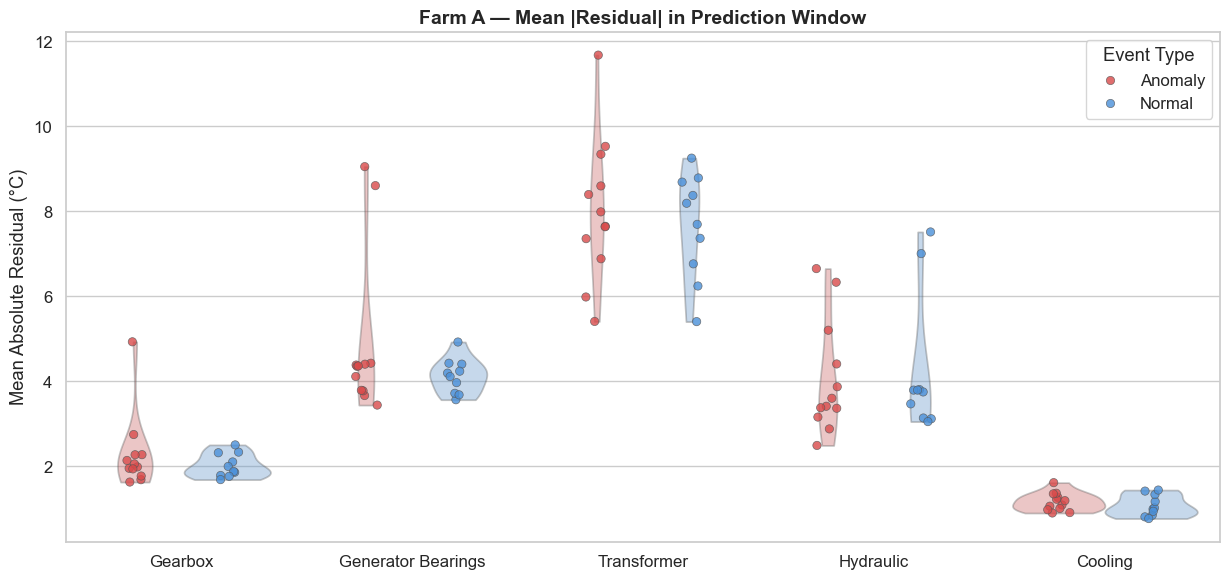

Saved: sanity_violin_farm_a.png


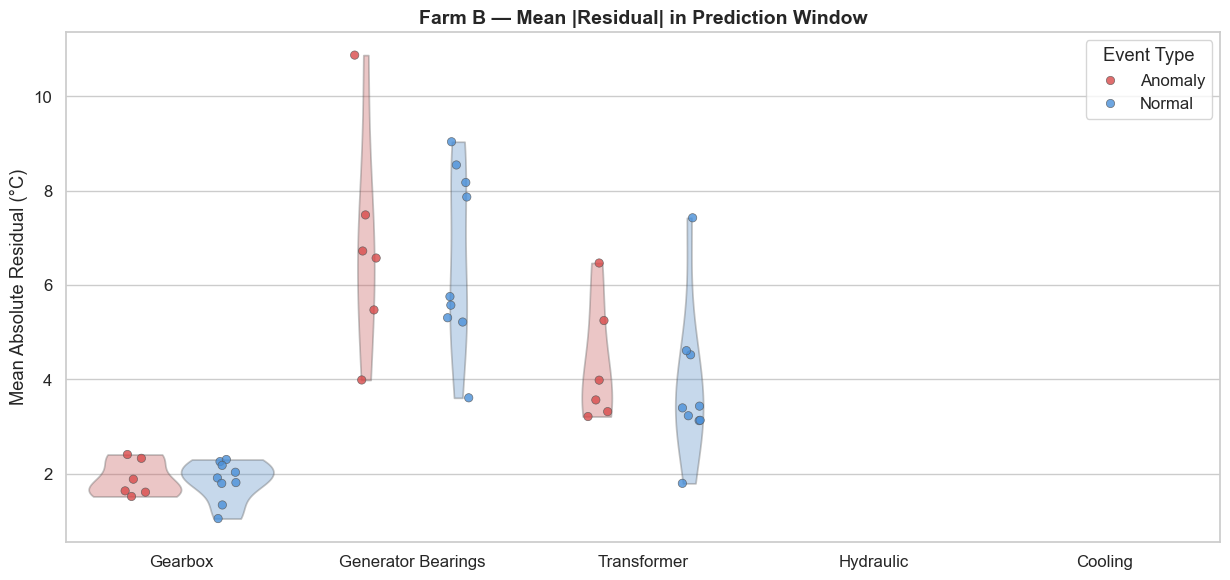

Saved: sanity_violin_farm_b.png


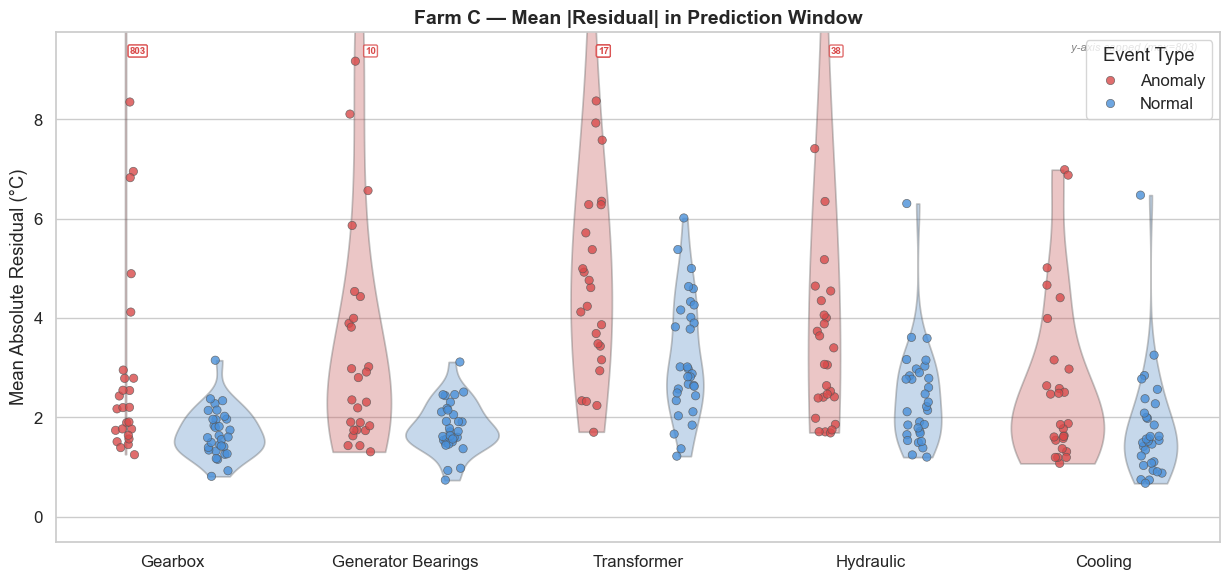

Saved: sanity_violin_farm_c.png


In [3]:
violin_figures = {}

for farm in FARMS:
    farm_data = all_event_stats[all_event_stats["farm"] == farm.upper()].copy()
    if farm_data.empty:
        continue

    # identify available subsystems for this farm
    mean_abs_cols = [c for c in farm_data.columns if c.endswith("_mean_abs")]
    subsystems = [c.replace("_mean_abs", "") for c in mean_abs_cols]

    # melt to long form for seaborn
    melt_df = farm_data.melt(
        id_vars=["event_id", "event_label"],
        value_vars=mean_abs_cols,
        var_name="subsystem_raw",
        value_name="mean_abs_residual",
    )
    melt_df["Subsystem"] = melt_df["subsystem_raw"].str.replace("_mean_abs", "").map(SUBSYSTEM_LABELS)
    melt_df["Event Type"] = melt_df["event_label"].str.capitalize()

    # detect extreme outliers — cap y-axis at a reasonable percentile if needed
    p99 = melt_df["mean_abs_residual"].quantile(0.95)
    max_val = melt_df["mean_abs_residual"].max()
    has_outliers = max_val > p99 * 3  # extreme skew

    n_subs = len(subsystems)
    fig, ax = plt.subplots(figsize=(max(12, n_subs * 2.5), 6))

    # combined violin + strip for individual events
    sns.violinplot(
        data=melt_df,
        x="Subsystem",
        y="mean_abs_residual",
        hue="Event Type",
        split=False,
        inner=None,
        palette={"Normal": "#4A90D9", "Anomaly": "#D94A4A"},
        alpha=0.35,
        ax=ax,
        cut=0,
    )
    sns.stripplot(
        data=melt_df,
        x="Subsystem",
        y="mean_abs_residual",
        hue="Event Type",
        palette={"Normal": "#4A90D9", "Anomaly": "#D94A4A"},
        dodge=True,
        size=6,
        alpha=0.8,
        ax=ax,
        edgecolor="gray",
        linewidth=0.5,
    )

    # if extreme outliers exist, cap the y-axis and annotate
    if has_outliers:
        y_cap = p99 * 1.4
        ax.set_ylim(-0.5, y_cap)
        # annotate clipped points
        clipped = melt_df[melt_df["mean_abs_residual"] > y_cap]
        for _, cp in clipped.iterrows():
            ax.annotate(
                f"{cp['mean_abs_residual']:.0f}",
                xy=(list(SUBSYSTEM_LABELS.values()).index(cp["Subsystem"]) - 0.15
                    if cp["Event Type"] == "Anomaly" else
                    list(SUBSYSTEM_LABELS.values()).index(cp["Subsystem"]) + 0.15,
                    y_cap * 0.97),
                fontsize=7, color="#D94A4A", fontweight="bold",
                ha="center", va="top",
                bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="#D94A4A", alpha=0.8),
            )
        ax.text(0.98, 0.98, f"y-axis capped (max={max_val:.0f})",
                transform=ax.transAxes, fontsize=8, ha="right", va="top",
                style="italic", color="gray")

    # de-duplicate legend entries
    handles, labels = ax.get_legend_handles_labels()
    unique = dict(zip(labels, handles))
    ax.legend(unique.values(), unique.keys(), title="Event Type", loc="upper right")

    ax.set_title(f"{FARM_LABELS[farm]} — Mean |Residual| in Prediction Window", fontsize=14, fontweight="bold")
    ax.set_ylabel("Mean Absolute Residual (°C)")
    ax.set_xlabel("")
    plt.tight_layout()

    fname = f"sanity_violin_{FARM_LABELS[farm].replace(' ', '_').lower()}.png"
    fig.savefig(FIGURES_DIR / fname, dpi=150, bbox_inches="tight")
    violin_figures[farm] = fname
    plt.show()
    print(f"Saved: {fname}")

## Statistical Significance: Are Anomaly Residuals Different?

We use the **Mann-Whitney U test** (non-parametric, no normality assumption) to test whether anomaly residuals are significantly larger than normal residuals for each farm-subsystem pair. Effect size is reported as **rank-biserial correlation** (r = 1 - 2U/(n1*n2)), where values closer to -1 or +1 indicate strong separation.

In [4]:
stat_rows = []

for farm in FARMS:
    farm_data = all_event_stats[all_event_stats["farm"] == farm.upper()]
    mean_abs_cols = [c for c in farm_data.columns if c.endswith("_mean_abs")]
    subsystems = [c.replace("_mean_abs", "") for c in mean_abs_cols]

    normal = farm_data[farm_data["event_label"] == "normal"]
    anomaly = farm_data[farm_data["event_label"] == "anomaly"]

    for sub in subsystems:
        col = f"{sub}_mean_abs"
        norm_vals = normal[col].dropna().values
        anom_vals = anomaly[col].dropna().values

        if len(norm_vals) < 2 or len(anom_vals) < 2:
            continue

        # Mann-Whitney U: alternative='less' tests if normal < anomaly
        u_stat, p_val = mannwhitneyu(norm_vals, anom_vals, alternative="less")

        # rank-biserial correlation as effect size
        n1, n2 = len(norm_vals), len(anom_vals)
        rank_biserial = 1 - (2 * u_stat) / (n1 * n2)

        # significance flags
        if p_val < 0.01:
            sig = "**"
        elif p_val < 0.05:
            sig = "*"
        else:
            sig = "ns"

        stat_rows.append({
            "Farm": FARM_LABELS[farm],
            "Subsystem": SUBSYSTEM_LABELS.get(sub, sub),
            "Normal Mean": f"{norm_vals.mean():.2f}",
            "Anomaly Mean": f"{anom_vals.mean():.2f}",
            "U Statistic": f"{u_stat:.0f}",
            "p-value": f"{p_val:.4f}" if p_val >= 0.0001 else f"{p_val:.2e}",
            "Rank-Biserial r": f"{rank_biserial:.3f}",
            "Sig.": sig,
            # store raw values for JSON report
            "_farm": farm,
            "_sub": sub,
            "_p_raw": p_val,
            "_normal_mean": float(norm_vals.mean()),
            "_anomaly_mean": float(anom_vals.mean()),
            "_rank_biserial": float(rank_biserial),
        })

stat_df = pd.DataFrame(stat_rows)

# display clean table
display_cols = ["Farm", "Subsystem", "Normal Mean", "Anomaly Mean",
                "U Statistic", "p-value", "Rank-Biserial r", "Sig."]
print("Mann-Whitney U Test Results (H1: anomaly residuals > normal residuals)")
print("=" * 100)
display(stat_df[display_cols].style.set_properties(**{"text-align": "center"}))

Mann-Whitney U Test Results (H1: anomaly residuals > normal residuals)


,Farm,Subsystem,Normal Mean,Anomaly Mean,U Statistic,p-value,Rank-Biserial r,Sig.
0,Farm A,Gearbox,2.02,2.28,56,0.4087,0.067,ns
1,Farm A,Generator Bearings,4.12,4.86,51,0.2876,0.150,ns
2,Farm A,Transformer,7.67,8.03,55,0.3833,0.083,ns
3,Farm A,Hydraulic,4.24,4.06,64,0.6167,-0.067,ns
4,Farm A,Cooling,1.07,1.16,46,0.1867,0.233,ns
5,Farm B,Gearbox,1.85,1.90,26,0.4773,0.037,ns
6,Farm B,Generator Bearings,6.57,6.85,26,0.4773,0.037,ns
7,Farm B,Transformer,3.85,4.30,19,0.1942,0.296,ns
8,Farm C,Gearbox,1.69,60.69,197,0.0003,0.529,**
9,Farm C,Generator Bearings,1.80,3.55,200,0.0003,0.522,**


## Per-Event Residual Heatmap

A bird's-eye view across all events and subsystems. Rows are events (grouped by farm, sorted by label), columns are subsystems. Cell color encodes mean absolute residual in the prediction window. Y-axis labels show event label (**A** = anomaly, **N** = normal) so we can visually confirm that hot rows cluster among anomalies.

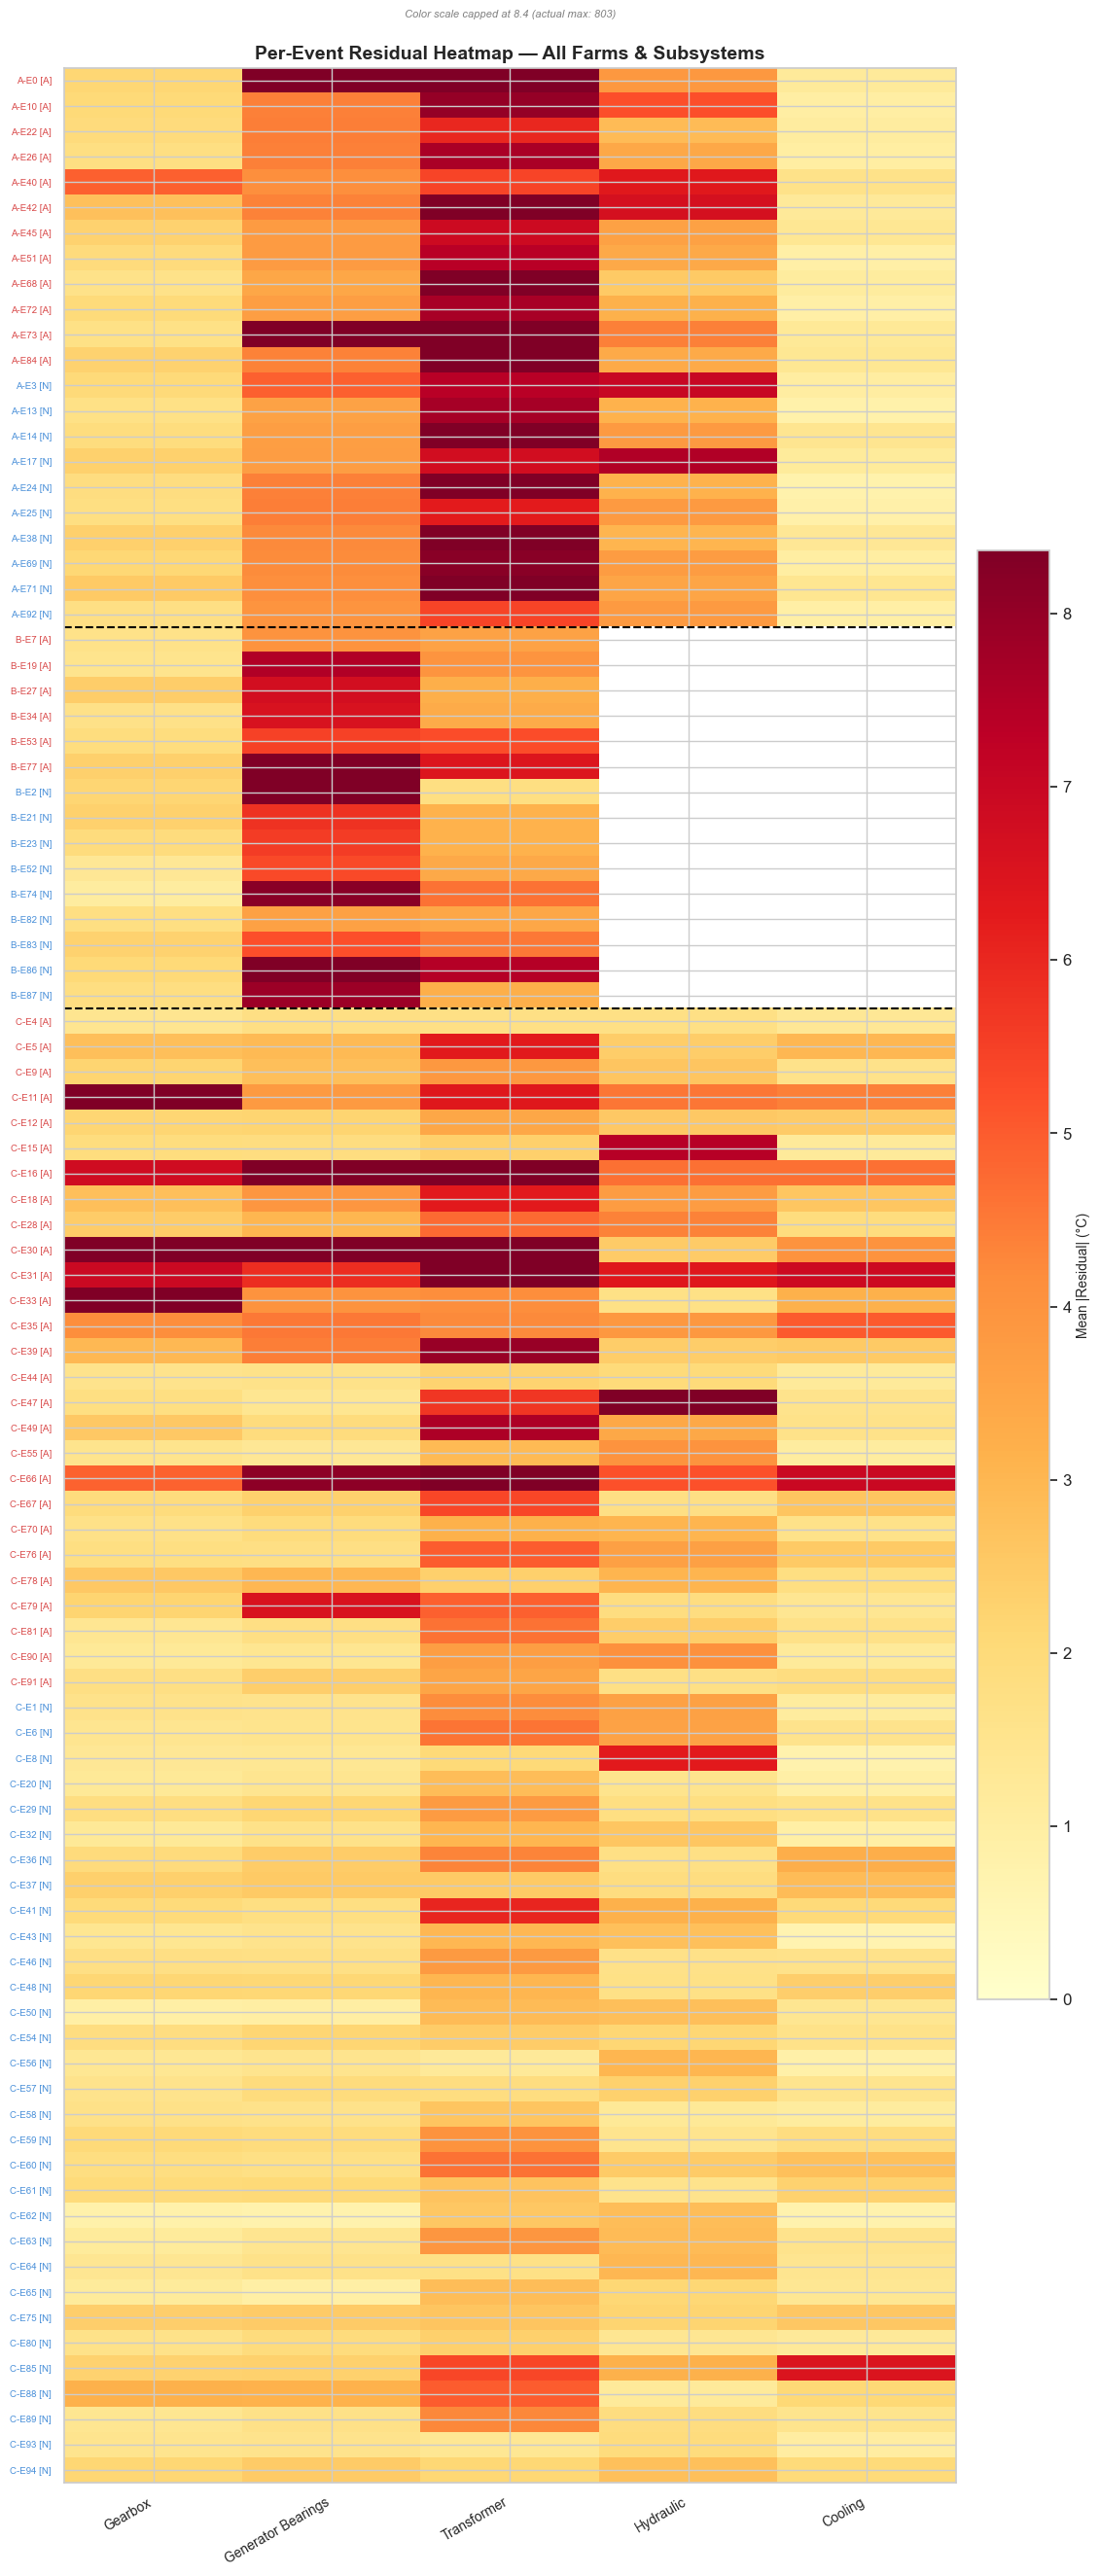

Saved: sanity_residual_heatmap.png


In [5]:
# build heatmap matrix
# all subsystems across all farms (union)
all_subsystems = ["gearbox", "generator_bearings", "transformer", "hydraulic", "cooling"]

# sort: by farm, then anomaly first, then event_id
heatmap_df = all_event_stats.copy()
heatmap_df["sort_label"] = heatmap_df["event_label"].map({"anomaly": 0, "normal": 1})
heatmap_df = heatmap_df.sort_values(["farm", "sort_label", "event_id"]).reset_index(drop=True)

# build the matrix
heat_matrix = []
y_labels = []
for _, row in heatmap_df.iterrows():
    label_char = "A" if row["event_label"] == "anomaly" else "N"
    y_labels.append(f"{row['farm']}-E{int(row['event_id'])} [{label_char}]")
    vals = []
    for sub in all_subsystems:
        col = f"{sub}_mean_abs"
        vals.append(row.get(col, np.nan))
    heat_matrix.append(vals)

heat_arr = np.array(heat_matrix)
col_labels = [SUBSYSTEM_LABELS[s] for s in all_subsystems]

# cap the color scale at 95th percentile so extreme outliers don't wash out detail
vmax_cap = np.nanpercentile(heat_arr, 95)
actual_max = np.nanmax(heat_arr)
if actual_max > vmax_cap * 3:
    vmax = vmax_cap
    cap_note = f"Color scale capped at {vmax:.1f} (actual max: {actual_max:.0f})"
else:
    vmax = None
    cap_note = None

fig, ax = plt.subplots(figsize=(12, max(10, len(y_labels) * 0.28)))
im = ax.imshow(heat_arr, aspect="auto", cmap="YlOrRd", interpolation="nearest",
               vmin=0, vmax=vmax)

ax.set_xticks(range(len(col_labels)))
ax.set_xticklabels(col_labels, rotation=30, ha="right", fontsize=10)
ax.set_yticks(range(len(y_labels)))
ax.set_yticklabels(y_labels, fontsize=7)

# color y-tick labels by type
for i, lbl in enumerate(y_labels):
    color = "#D94A4A" if "[A]" in lbl else "#4A90D9"
    ax.get_yticklabels()[i].set_color(color)

# draw farm separator lines
farms_in_order = heatmap_df["farm"].values
for i in range(1, len(farms_in_order)):
    if farms_in_order[i] != farms_in_order[i - 1]:
        ax.axhline(y=i - 0.5, color="black", linewidth=1.5, linestyle="--")

cbar = fig.colorbar(im, ax=ax, shrink=0.6, pad=0.02)
cbar.set_label("Mean |Residual| (°C)", fontsize=10)

title = "Per-Event Residual Heatmap — All Farms & Subsystems"
ax.set_title(title, fontsize=14, fontweight="bold")
if cap_note:
    ax.text(0.5, 1.02, cap_note, transform=ax.transAxes,
            fontsize=8, ha="center", va="bottom", style="italic", color="gray")

plt.tight_layout()

fname = "sanity_residual_heatmap.png"
fig.savefig(FIGURES_DIR / fname, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {fname}")

## Best and Worst Detection Cases

We identify:
- **Best detections** — anomaly events with the largest mean residuals (model clearly flagged them)
- **Missed detections** — anomaly events where residuals stayed near zero (model didn't catch them)
- **False alarm candidates** — normal events with unexpectedly elevated residuals

In [6]:
# compute an overall "max subsystem mean_abs" per event as the detection signal
mean_abs_cols = [c for c in all_event_stats.columns if c.endswith("_mean_abs")]
all_event_stats["max_mean_abs"] = all_event_stats[mean_abs_cols].max(axis=1)
all_event_stats["avg_mean_abs"] = all_event_stats[mean_abs_cols].mean(axis=1)

anomalies = all_event_stats[all_event_stats["event_label"] == "anomaly"].copy()
normals = all_event_stats[all_event_stats["event_label"] == "normal"].copy()

display_cols_det = ["farm", "event_id", "asset_id", "event_description", "max_mean_abs", "avg_mean_abs"]
col_rename = {
    "farm": "Farm", "event_id": "Event", "asset_id": "Asset",
    "event_description": "Description", "max_mean_abs": "Max |Resid|", "avg_mean_abs": "Avg |Resid|",
}

# --- TOP 5 BEST DETECTIONS (anomaly with largest residuals) ---
best = anomalies.nlargest(5, "max_mean_abs")[display_cols_det].rename(columns=col_rename)
print("TOP 5 BEST DETECTIONS (anomalies with largest residuals)")
print("=" * 90)
display(best.reset_index(drop=True))

# --- MISSED DETECTIONS (anomaly with residuals near zero) ---
# threshold: max_mean_abs < median of normal events' max_mean_abs
normal_median = normals["max_mean_abs"].median()
missed = anomalies[anomalies["max_mean_abs"] <= normal_median].sort_values("max_mean_abs")
print(f"\nMISSED DETECTIONS (anomaly max |residual| <= normal median {normal_median:.2f})")
print("=" * 90)
if missed.empty:
    print("None — all anomaly events have residuals above the normal median. Good news!")
else:
    display(missed[display_cols_det].rename(columns=col_rename).reset_index(drop=True))

# --- FALSE ALARM CANDIDATES (normal with elevated residuals) ---
# threshold: normal events whose max_mean_abs exceeds 75th percentile of anomalies
anom_p25 = anomalies["max_mean_abs"].quantile(0.25)
false_alarms = normals[normals["max_mean_abs"] >= anom_p25].sort_values("max_mean_abs", ascending=False)
print(f"\nFALSE ALARM CANDIDATES (normal max |residual| >= anomaly 25th pctile {anom_p25:.2f})")
print("=" * 90)
if false_alarms.empty:
    print("None — no normal events have residuals overlapping with anomalies. Clean separation!")
else:
    display(false_alarms[display_cols_det].rename(columns=col_rename).reset_index(drop=True))

TOP 5 BEST DETECTIONS (anomalies with largest residuals)


,Farm,Event,Asset,Description,Max |Resid|,Avg |Resid|
0,C,11,43,P20_DGUV-v3 RCD 28F1 NC310 defective + 0 : P20...,802.835445,164.390756
1,C,33,43,P20_Blade3_Grease Collector missing,764.098008,155.411982
2,C,47,21,Failure due to Rotorbrake and Hydraulic proble...,38.463510,9.783851
3,C,30,16,Pitch failure - defect fan on pitch motor,17.163643,8.424333
4,C,16,53,WEC in failure - hub battery charger defect,17.016982,8.462509



MISSED DETECTIONS (anomaly max |residual| <= normal median 4.30)


,Farm,Event,Asset,Description,Max |Resid|,Avg |Resid|
0,C,4,34,23020 : Axis 3 not ready-to-operate,1.748714,1.585180
1,C,44,44,Valve in water cooling system was left in wron...,2.240532,1.723706
2,C,78,15,P20_Grounding role brake disc + P20_cover-ligh...,3.056614,2.535142
3,C,70,23,"21002 : Axis 1 DC-link voltage low, batt",3.159756,2.278404
4,C,12,2,"10115 : Oil level error, two-pump mode + Oil L...",3.434424,2.559051
5,C,91,42,23020 : Axis 3 not ready-to-operate,3.483221,2.229316
6,C,9,55,PENDING19_PREV_YAW_Grease pump defective,3.864779,2.617512
7,B,7,13,high temperature in transformer cell,3.987629,3.053745
8,C,55,50,Harting plug Nacelle/HUB damaged + NCR20_HUB: ...,4.005089,2.168326
9,C,90,56,COMMUNICATION FAULT BK1120 IN NC300 A2,4.059886,2.325626



FALSE ALARM CANDIDATES (normal max |residual| >= anomaly 25th pctile 4.76)


,Farm,Event,Asset,Description,Max |Resid|,Avg |Resid|
0,A,71,0,NaN,9.248273,4.148987
1,B,86,12,NaN,9.037692,6.164771
2,A,38,13,NaN,8.781862,3.947402
3,A,14,13,NaN,8.684585,3.894625
4,B,2,13,NaN,8.545827,4.172993
5,A,24,0,NaN,8.370844,3.707474
6,A,69,11,NaN,8.186644,3.844333
7,B,74,11,NaN,8.173768,4.610836
8,B,87,7,NaN,7.866913,4.302827
9,A,13,21,NaN,7.690773,3.373900


In [7]:
# --- Save sanity check report JSON ---
report = {
    "statistical_tests": {},
    "best_detections": [],
    "missed_detections": [],
    "false_alarm_candidates": [],
}

# statistical tests
for _, r in stat_df.iterrows():
    farm_key = r["_farm"].upper()
    sub_key = r["_sub"]
    if farm_key not in report["statistical_tests"]:
        report["statistical_tests"][farm_key] = {}
    report["statistical_tests"][farm_key][sub_key] = {
        "normal_mean_abs": round(r["_normal_mean"], 4),
        "anomaly_mean_abs": round(r["_anomaly_mean"], 4),
        "p_value": round(r["_p_raw"], 6),
        "rank_biserial": round(r["_rank_biserial"], 4),
        "significant_05": r["_p_raw"] < 0.05,
        "significant_01": r["_p_raw"] < 0.01,
    }

# best detections (top 5)
for _, r in anomalies.nlargest(5, "max_mean_abs").iterrows():
    report["best_detections"].append({
        "farm": r["farm"],
        "event_id": int(r["event_id"]),
        "description": str(r.get("event_description", "")),
        "max_mean_abs_residual": round(float(r["max_mean_abs"]), 4),
        "avg_mean_abs_residual": round(float(r["avg_mean_abs"]), 4),
    })

# missed detections
for _, r in missed.iterrows():
    report["missed_detections"].append({
        "farm": r["farm"],
        "event_id": int(r["event_id"]),
        "description": str(r.get("event_description", "")),
        "max_mean_abs_residual": round(float(r["max_mean_abs"]), 4),
        "avg_mean_abs_residual": round(float(r["avg_mean_abs"]), 4),
    })

# false alarm candidates
for _, r in false_alarms.iterrows():
    report["false_alarm_candidates"].append({
        "farm": r["farm"],
        "event_id": int(r["event_id"]),
        "max_mean_abs_residual": round(float(r["max_mean_abs"]), 4),
        "avg_mean_abs_residual": round(float(r["avg_mean_abs"]), 4),
    })

report_path = REPORTS_DIR / "residual_sanity_check.json"
with open(report_path, "w") as f:
    json.dump(report, f, indent=2)

print(f"Sanity check report saved to: {report_path}")
print(f"\nSummary:")
print(f"  Significant tests (p<0.05): {sum(1 for r in stat_rows if r['_p_raw'] < 0.05)} / {len(stat_rows)}")
print(f"  Best detections: {len(report['best_detections'])}")
print(f"  Missed detections: {len(report['missed_detections'])}")
print(f"  False alarm candidates: {len(report['false_alarm_candidates'])}")

Sanity check report saved to: D:\Personal Projects\Enbridge Case Compettion\outputs\reports\residual_sanity_check.json

Summary:
  Significant tests (p<0.05): 5 / 13
  Best detections: 5
  Missed detections: 10
  False alarm candidates: 22


## Key Observations

**Residual Separation:**
- _[Fill in after running: Do anomaly residuals clearly exceed normal residuals across subsystems?]_

**Statistical Significance:**
- _[Fill in: How many farm-subsystem pairs show significant separation (p < 0.05)?]_
- _[Fill in: Which subsystems have the strongest effect sizes?]_

**Detection Quality:**
- _[Fill in: Which fault types are easiest to detect (largest residuals)?]_
- _[Fill in: Are there any missed anomalies? What characterizes them?]_
- _[Fill in: Are there false alarm candidates among normal events?]_

**Implications for Phase 4 (Anomaly Detection):**
- _[Fill in: Based on these results, which subsystems are most reliable for anomaly detection?]_
- _[Fill in: Should thresholds be subsystem-specific or farm-specific?]_
- _[Fill in: Any events that need special handling in threshold calibration?]_